Analysis of Insurance data set final project

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
insurance_df = pd.read_csv("insurance.csv")               # data load
insurance_df    

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [105]:
insurance_df.info()                             # data information basics

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [106]:
insurance_df.describe()                           # data calculations

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [107]:
null_sum = insurance_df.isnull().sum()        #sum of null values check
null_sum

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [108]:
insurance_df.isnull()                             #null value boolean check

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [109]:
insurance_df['sex'] = insurance_df['sex'].map({'male': 0, 'female': 1})    #encoding sex value
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [110]:
insurance_df['smoker'] = insurance_df['smoker'].map({'yes': 1, 'no': 0})
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [111]:
# droppping column region
insurance_df.drop(columns=["region"])

,age,sex,bmi,children,smoker,charges
0,19,1,27.900,0,1,16884.92400
1,18,0,33.770,1,0,1725.55230
2,28,0,33.000,3,0,4449.46200
3,33,0,22.705,0,0,21984.47061
4,32,0,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830
1334,18,1,31.920,0,0,2205.98080
1335,18,1,36.850,0,0,1629.83350
1336,21,1,25.800,0,0,2007.94500


Inter Quartile Range calculation and Outlier detection
Plot using Box plot of INsurance data for age, charges, bmi

In [112]:
# intitializing Quartile 1 and 2
Q1 = insurance_df["age"].quantile(0.25)
Q3 = insurance_df["age"].quantile(0.75)
#calculate IQR
IQR = Q3-Q1
lower_bound = Q1 -IQR * 1.5
upper_bound = Q3 +IQR * 1.5
print("IQR: ", IQR)
print(f"Lower bound : {lower_bound:.3f}")
print(f"upper bound : {upper_bound:.3f}")



IQR:  24.0
Lower bound : -9.000
upper bound : 87.000


In [113]:
#filter the dataframe for outliers
outliers = insurance_df[(insurance_df["age"]< lower_bound) | (insurance_df["age"]> upper_bound)]
print(f"Total Rows: {len(insurance_df)}")
print(f"Outlier Rows: {len(outliers)}")

Total Rows: 1338
Outlier Rows: 0


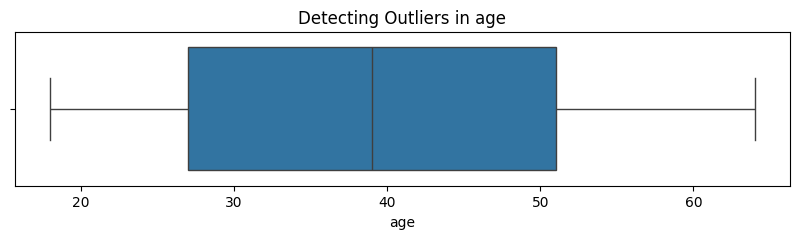

In [114]:
# Visualize with a box plot
plt.figure(figsize = (10,2)) # 10 inches wide and 2 inches tall for the canvas
sns.boxplot(x = insurance_df["age"])
plt.title(f"Detecting Outliers in age")
plt.show()

In [115]:
# keep only the data within the bounds
df_cleaned = insurance_df[(insurance_df["age"] >= lower_bound) & (insurance_df["age"] <= upper_bound)]
print(f"Shape before {insurance_df.shape}")                        # shape gives row ,columns
print(f"Shape after {df_cleaned.shape}")

Shape before (1338, 7)
Shape after (1338, 7)


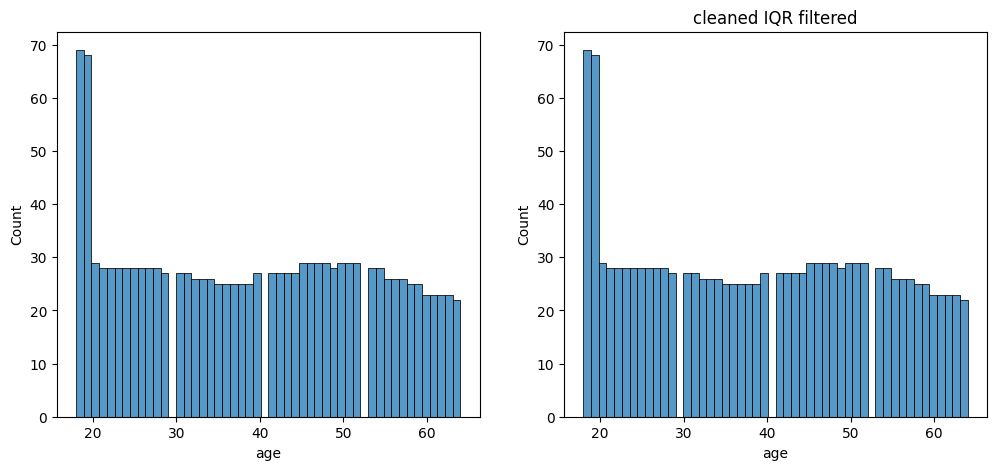

In [116]:
# compare the distribution before and after outlier cleaning
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.histplot(insurance_df["age"], bins = 50, ax = ax[0])
plt.title("Original with outliers")
# bins = 50 divides the data into 50 evenly spaced bars
sns.histplot(df_cleaned["age"], bins = 50, ax = ax[1])
plt.title("cleaned IQR filtered")
plt.show()

In [117]:
# for charges column
# # intitializing Quartile 1 and 2
Q1 = insurance_df["charges"].quantile(0.25)
Q3 = insurance_df["charges"].quantile(0.75)
#calculate IQR
IQR = Q3-Q1
lower_bound = Q1 -IQR * 1.5
upper_bound = Q3 +IQR * 1.5
print("IQR: ", IQR)
print(f"Lower bound : {lower_bound:.3f}")
print(f"upper bound : {upper_bound:.3f}")

IQR:  11899.625365
Lower bound : -13109.151
upper bound : 34489.351


In [118]:
#filter the dataframe for outliers
outliers = insurance_df[(insurance_df["charges"]< lower_bound) | (insurance_df["charges"]> upper_bound)]
print(f"Total Rows: {len(insurance_df)}")
print(f"Outlier Rows: {len(outliers)}")
  

Total Rows: 1338
Outlier Rows: 139


In [119]:
# print only outliers charges column
outliers["charges"]

14      39611.75770
19      36837.46700
23      37701.87680
29      38711.00000
30      35585.57600
           ...     
1300    62592.87309
1301    46718.16325
1303    37829.72420
1313    36397.57600
1323    43896.37630
Name: charges, Length: 139, dtype: float64

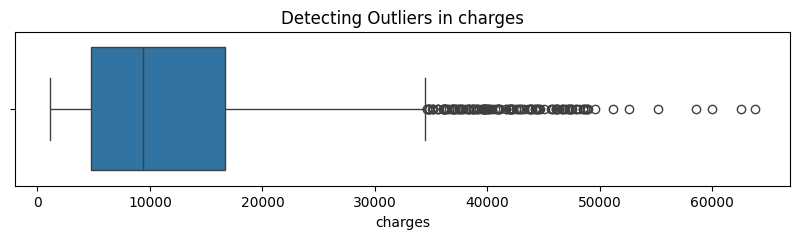

In [120]:
# Visualize with a box plot
plt.figure(figsize = (10,2)) # 10 inches wide and 2 inches tall for the canvas
sns.boxplot(x = insurance_df["charges"])
plt.title(f"Detecting Outliers in charges")
plt.show()

In [121]:
# keep only the data within the bounds
df_cleaned = insurance_df[(insurance_df["charges"] >= lower_bound) & (insurance_df["charges"] <= upper_bound)]
print(f"Shape before {insurance_df.shape}")                        # shape gives row ,columns
print(f"Shape after {df_cleaned.shape}")

Shape before (1338, 7)
Shape after (1199, 7)


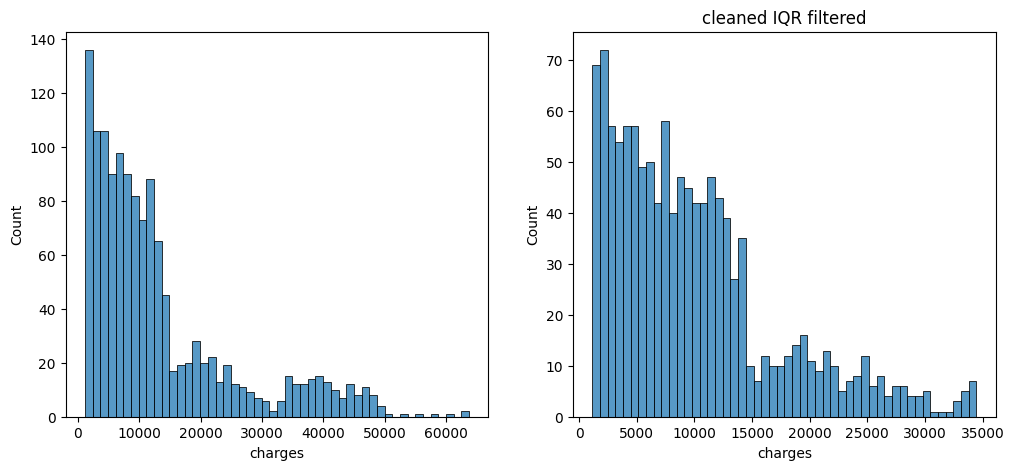

In [122]:
# compare the distribution before and after outlier cleaning
fig, ax = plt.subplots(1,2, figsize = (12,5))
sns.histplot(insurance_df["charges"], bins = 50, ax = ax[0])
plt.title("Original with outliers")
# bins = 50 divides the data into 50 evenly spaced bars
sns.histplot(df_cleaned["charges"], bins = 50, ax = ax[1])
plt.title("cleaned IQR filtered")
plt.show()

Scaling of Insurance DataSet with standardized, Normalized, Robust

In [123]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler

In [124]:
#initialize scalers
std_scalers = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

In [125]:
#create a comparison Dataframe 
insurance_2d = insurance_df["bmi"].values.reshape(-1,1) 
results = pd.DataFrame({
    "Original" : insurance_df["bmi"],
    "Standardized (Z-score)" : std_scalers.fit_transform(insurance_2d).flatten(),
    "Normalized (0-1)" : minmax_scaler.fit_transform(insurance_2d).flatten(),
    "Robust (IQR)" : robust_scaler.fit_transform(insurance_2d).flatten()
})
print(results)

      Original  Standardized (Z-score)  Normalized (0-1)  Robust (IQR)
0       27.900               -0.453320          0.321227     -0.297708
1       33.770                0.509621          0.479150      0.401310
2       33.000                0.383307          0.458434      0.309616
3       22.705               -1.305531          0.181464     -0.916344
4       28.880               -0.292556          0.347592     -0.181006
...        ...                     ...               ...           ...
1333    30.970                0.050297          0.403820      0.067877
1334    31.920                0.206139          0.429379      0.181006
1335    36.850                1.014878          0.562012      0.768086
1336    25.800               -0.797813          0.264730     -0.547782
1337    29.070               -0.261388          0.352704     -0.158380

[1338 rows x 4 columns]


Correlation and Data Analysis of Insurance dataset
r coefficient calculation and scatter plot

In [126]:
bmi_charges_corr = insurance_df[["bmi", "charges"]].corr()
bmi_charges_corr

,bmi,charges
bmi,1.000000,0.198341
charges,0.198341,1.000000


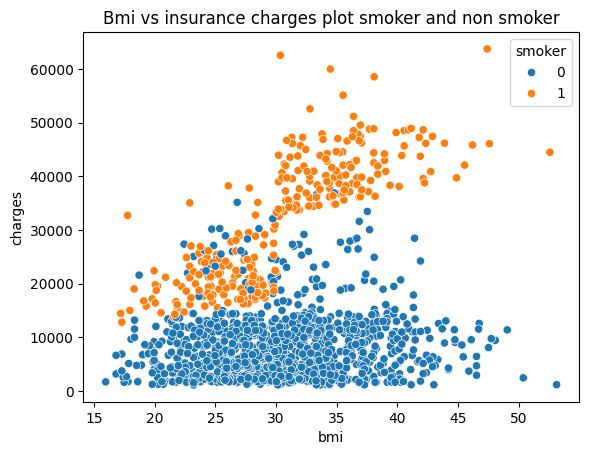

In [127]:
sns.scatterplot(data=insurance_df, x = "bmi", y = "charges", hue = "smoker")
plt.title("Bmi vs insurance charges plot smoker and non smoker")
plt.show()

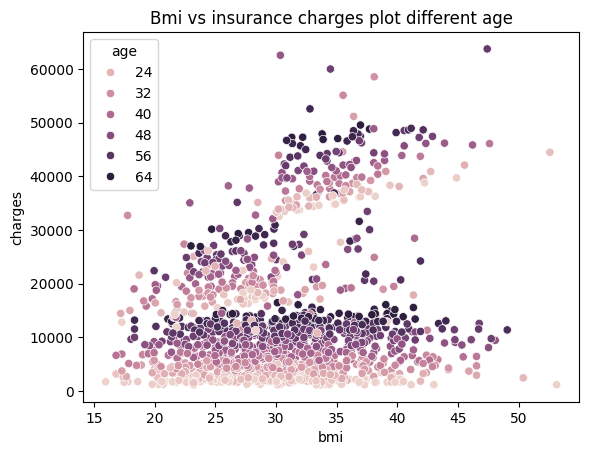

In [128]:
sns.scatterplot(data=insurance_df, x = "bmi", y = "charges", hue = "age")
plt.title("Bmi vs insurance charges plot different age")
plt.show()

In [129]:
combined_corr = insurance_df.corr(numeric_only=True)
combined_corr

,age,sex,bmi,children,smoker,charges
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000


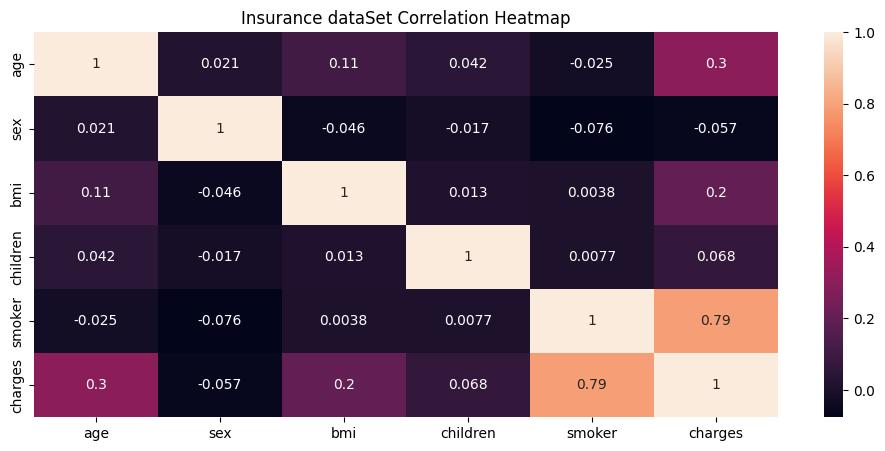

In [130]:
#Heat MAP for insurance data
plt.figure(figsize=(12,5))
sns.heatmap(combined_corr, annot = True)
plt.title("Insurance dataSet Correlation Heatmap")
plt.show()

Applying T test on charges of insurance after 10% VAT was imposed on charges

In [134]:
# Increment charges by 10% VAT
insurance_df["charges_V"] = insurance_df["charges"] + 0.1 * insurance_df["charges"]
insurance_df[["charges", "charges_V"]]

,charges,charges_V
0,16884.92400,18573.416400
1,1725.55230,1898.107530
2,4449.46200,4894.408200
3,21984.47061,24182.917671
4,3866.85520,4253.540720
...,...,...
1333,10600.54830,11660.603130
1334,2205.98080,2426.578880
1335,1629.83350,1792.816850
1336,2007.94500,2208.739500


In [136]:
from scipy import stats
# charges wihout imposing 10% VAT
charge_a = insurance_df["charges"]
# charges after imposing 10% VAT
charge_b = insurance_df["charges_V"]

t_stat, p_val = stats.ttest_ind(charge_a, charge_b)
print(f"p_value : {p_val:.4f}")
if p_val < 0.05:
    print("The VAT significantly increased charges")
else:
    print("The difference might just be luck")


p_value : 0.0071
The VAT significantly increased charges
